# Purpose
- For research quick execution
- Minimum parameters input

# Parameter list

In [ ]:
PROJECT_FOLDER = '/content/drive/MyDrive/Classroom/AI2024/mini_researches/Proposals/CommonTools'
IMAGE_FOLDER_VAL = '/content/drive/MyDrive/Classroom/AI2024/mini_researches/Proposals/CommonTools/data/bdd100k/bdd100k/images/100k/val'
IMAGE_FOLDER_TRAIN = '/content/drive/MyDrive/Classroom/AI2024/mini_researches/Proposals/CommonTools/data/bdd100k/bdd100k/images/100k/train'
SCENE_FOLDER = f"{PROJECT_FOLDER}/scene"
SCENE_FILE_LOCATION = "/content/drive/MyDrive/Classroom/AI2024/mini_researches/Proposals/JiahengLyu/project/Calculating_RGB_Results"

base_url = "https://dl.cv.ethz.ch/bdd100k/data"
files = [
    "100k_images_val.zip",
    "100k_images_train.zip",
    "100k_images_test.zip",
    "bdd100k_det_20_labels_trainval.zip"
]

zip_files = [
    f"{PROJECT_FOLDER}/data/100k_images_val.zip",
    f"{PROJECT_FOLDER}/data/100k_images_train.zip",
    f"{PROJECT_FOLDER}/data/100k_images_test.zip",
    f"{PROJECT_FOLDER}/data/bdd100k_det_20_labels_trainval.zip"
]

train_label_unzipped_file = f'{PROJECT_FOLDER}/data/bdd100k/bdd100k/labels/det_20/det_train.json'
val_label_unzipped_file = f'{PROJECT_FOLDER}/data/bdd100k/bdd100k/labels/det_20/det_train.json'

import os
os.makedirs(SCENE_FOLDER, exist_ok=True)


# Categorize

In [ ]:
import json
import pandas as pd

def load_json_file(file_path):
    """
    Loads a JSON file and returns the data.
    """
    with open(file_path, 'r') as file:
        data = json.load(file)
    return data

def process_entry(entry):
    """
    Processes a single JSON entry to extract relevant information.
    """
    name = entry['name']
    weather = entry['attributes']['weather']
    timeofday = entry['attributes']['timeofday']
    scene = entry['attributes']['scene']

    if 'labels' in entry and entry['labels']:
        categories = ', '.join(set([label['category'] for label in entry['labels']]))
    else:
        categories = 'None'

    return {
        'name': name,
        'weather': weather,
        'timeofday': timeofday,
        'scene': scene,
        'categories': categories
    }

def process_json_data(json_data):
    """
    Processes a list of JSON data entries into a DataFrame.
    """
    processed_data = [process_entry(entry) for entry in json_data]
    df = pd.DataFrame(processed_data)
    return df

def save_dataframe_to_csv(df, output_file_path):
    """
    Saves a DataFrame to a CSV file.
    """
    df.to_csv(output_file_path, index=False)
    print(f"CSV file saved to {output_file_path}")

def categorieze(train_json_path, val_json_path, output_csv_file):
    """
    Main function to load JSON files, process them, and save to CSV.
    """
    # Load the JSON data
    train_data = load_json_file(train_json_path)
    val_data = load_json_file(val_json_path)

    # Combine the training and validation data
    combined_data = train_data + val_data

    # Process the combined data into a DataFrame
    df = process_json_data(combined_data)

    # Save the DataFrame to a CSV file
    save_dataframe_to_csv(df, output_csv_file)


In [ ]:
if 11 == 111:
    # Example usage
    train_label_unzipped_file = f'{PROJECT_FOLDER}/data/bdd100k/bdd100k/labels/det_20/det_train.json'
    val_label_unzipped_file = f'{PROJECT_FOLDER}/data/bdd100k/bdd100k/labels/det_20/det_val.json'
    output_csv_file = f'{SCENE_FOLDER}/image_categories_attr.csv'

    # Call the main function
    categorieze(train_label_unzipped_file, val_label_unzipped_file, output_csv_file)

# Which Scenes?

### Find out scenes

In [ ]:
import os
fils = os.listdir(IMAGE_FOLDER_VAL)
output_csv_file = f'{SCENE_FOLDER}/image_categories_attr.csv'
pd.read_csv(output_csv_file).head(2)

,name,weather,timeofday,scene,categories
0,0000f77c-6257be58.jpg,clear,daytime,city street,"car, traffic sign, traffic light"
1,0000f77c-62c2a288.jpg,clear,dawn/dusk,highway,"pedestrian, traffic sign"


In [ ]:
import pandas as pd
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

# Custom dataset class to handle image loading
class ImageDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.dataframe = dataframe
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, self.dataframe.iloc[idx, 0])
        #img_name = os.path.join(self.root_dir, self.dataframe.iloc[idx, 5])

        image = cv2.imread(img_name)

        # Apply any transformations if provided
        if self.transform:
            image = self.transform(image)

        if image is None:
            print(f"Warning: Failed to read image {img_name}")
            return None, None

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = torch.tensor(image).permute(2, 0, 1).float() / 255.0  # Normalize to [0, 1]

        return image, self.dataframe.iloc[idx, 3]

def count_by_scene(df):
    scene_counts = df.groupby('scene')['name'].count().to_dict()
    return scene_counts


def calculate_mean_std(dataloader):
    scene_rgb_sum = {}
    scene_rgb_count = {}
    scene_rgb_sq_sum = {}

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    for images, scenes in tqdm(dataloader, desc="Processing Images"):
        # Filter out None values
        images = [img for img in images if img is not None]
        scenes = [scn for img, scn in zip(images, scenes) if img is not None]

        if len(images) == 0:
            continue

        images = torch.stack(images).to(device)
        for i in range(len(images)):
            image = images[i]
            scene = scenes[i]
            if scene not in scene_rgb_sum:
                scene_rgb_sum[scene] = torch.zeros(3).to(device)
                scene_rgb_count[scene] = 0
                scene_rgb_sq_sum[scene] = torch.zeros(3).to(device)

            scene_rgb_sum[scene] += image.sum(dim=(1, 2))
            scene_rgb_count[scene] += image.shape[1] * image.shape[2]
            scene_rgb_sq_sum[scene] += (image ** 2).sum(dim=(1, 2))

    scene_mean_std = {}
    for scene in scene_rgb_sum:
        mean = scene_rgb_sum[scene] / scene_rgb_count[scene]
        std = torch.sqrt((scene_rgb_sq_sum[scene] / scene_rgb_count[scene]) - (mean ** 2))
        scene_mean_std[scene] = (mean.cpu().numpy(), std.cpu().numpy(), scene_rgb_count[scene])

    return scene_mean_std


def plot_results(scene_mean_std):
    scenes = list(scene_mean_std.keys())
    means = [scene_mean_std[scene][0] for scene in scenes]
    stds = [scene_mean_std[scene][1] for scene in scenes]

    fig, axes = plt.subplots(2, 1, figsize=(12, 12))
    fig, axes = plt.subplots(2, 1, figsize=(12, 12))

    # Plot stacked means
    indices = np.arange(len(scenes))
    axes[0].bar(indices, [mean[0] for mean in means], color='r', alpha=0.6, label='Red')
    axes[0].bar(indices, [mean[1] for mean in means], color='g', alpha=0.6, label='Green', bottom=[mean[0] for mean in means])
    axes[0].bar(indices, [mean[2] for mean in means], color='b', alpha=0.6, label='Blue', bottom=[sum(mean[:2]) for mean in means])
    axes[0].set_title('Mean RGB values by Scene')
    axes[0].set_ylabel('Mean Value')
    axes[0].legend()

    # Plot stacked standard deviations
    axes[1].bar(indices, [std[0] for std in stds], color='r', alpha=0.6, label='Red')
    axes[1].bar(indices, [std[1] for std in stds], color='g', alpha=0.6, label='Green', bottom=[std[0] for std in stds])
    axes[1].bar(indices, [std[2] for std in stds], color='b', alpha=0.6, label='Blue', bottom=[sum(std[:2]) for std in stds])
    axes[1].set_title('Standard Deviation of RGB values by Scene')
    axes[1].set_ylabel('Standard Deviation')
    axes[1].legend()

    # # Plot means
    # axes[0].bar(scenes, [mean[0] for mean in means], color='r', alpha=0.6, label='Red')
    # axes[0].bar(scenes, [mean[1] for mean in means], color='g', alpha=0.6, label='Green')
    # axes[0].bar(scenes, [mean[2] for mean in means], color='b', alpha=0.6, label='Blue')
    # axes[0].set_title('Mean RGB values by Scene')
    # axes[0].set_ylabel('Mean Value')
    # axes[0].legend()

    # # Plot standard deviations
    # axes[1].bar(scenes, [std[0] for std in stds], color='r', alpha=0.6, label='Red')
    # axes[1].bar(scenes, [std[1] for std in stds], color='g', alpha=0.6, label='Green')
    # axes[1].bar(scenes, [std[2] for std in stds], color='b', alpha=0.6, label='Blue')
    # axes[1].set_title('Standard Deviation of RGB values by Scene')
    # axes[1].set_ylabel('Standard Deviation')
    # axes[1].legend()

    for ax in axes:
        ax.set_xticklabels(scenes, rotation=45, ha='right')
        ax.grid(True)

    plt.tight_layout()
    plt.show()

def save_results(scene_mean_std, filename):
    with open(filename, 'w') as f:
        for scene, (mean, std) in scene_mean_std.items():
            f.write(f"Scene: {scene}\n")
            f.write(f"Mean: {mean}\n")
            f.write(f"Std: {std}\n\n")

def process_images_and_save_results(output_csv_file, root_folder, output_file=None,
                                    batch_size=32,
                                    num_workers=2,
                                    batche_size = 8888,
                                    start_batch_no = 0 ):
    ## start_batch_no: the new start batch
    # Load the dataset
    df = pd.read_csv(output_csv_file)
    image_list = os.listdir(root_folder)
    df_image = pd.DataFrame({"name": image_list})
    df = df.merge(df_image, on="name", how="inner")

    # Map scenes to categories
    scene_mapping = {
        'city street': "city street",
        'highway': "highway",
        'residential': "residential",
        'parking lot': "other",
        'undefined': "other",
        'tunnel': "other",
        'gas stations': "other"
    }
    df['scene'] = df['scene'].map(scene_mapping).fillna('other')

    rows = df.shape[0]
    start_batch_no_ = 0
    for i in range(0, rows, batche_size):

        if start_batch_no_ < start_batch_no:
            continue

        start_batch_no_ += 1

        df_ = df.iloc[i:(i+batche_size)]

        # Create the dataset
        dataset = ImageDataset(df_, root_folder)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

        # Calculate mean and standard deviation
        scene_mean_std = calculate_mean_std(dataloader)

        # Plot the results
        plot_results(scene_mean_std)

        if not output_file:
            output_file = f"{SCENE_FOLDER}/scene_mean_std_{str(start_batch_no_)}.txt"
        save_results(scene_mean_std, output_file)

        output_file = None

        print(f"{output_file} processed .... ")


def process_scene_counts(image_folder_train,
                         image_folder_val,
                         scene_folder,
                         scene_file_location,
                         batch_size=8888,
                         count_file_path=None):
    """
    !!!!!!!!!!!!! missed the count info in the previous function
    Process scene counts in batches and save the results to a CSV file.

    Parameters:
    - image_folder_train (str): Path to the training image folder.
    - image_folder_val (str): Path to the validation image folder.
    - scene_folder (str): Path to the folder containing the scene information.
    - scene_file_location (str): Path to save the count by batch CSV file.
    - batch_size (int): Number of rows per batch. Default is 8888.
    - count_file_path (str): Path to save the count file. If None, a default path is used.

    Returns:
    - pd.DataFrame: The resulting DataFrame with scene counts by batch.
    """
    # Load the data from the specified CSV file
    output_csv_file = f'{scene_folder}/image_categories_attr.csv'
    df = pd.read_csv(output_csv_file)

    # Get the list of images from the training folder
    image_list = os.listdir(image_folder_train)
    df_image = pd.DataFrame({"name": image_list})

    # Merge the DataFrame with the list of images
    df = df.merge(df_image, on="name", how="inner")

    # Initialize variables for processing
    rows = df.shape[0]
    start_batch_no_ = 0
    count_dictionaries = []

    # Process the DataFrame in batches
    for i in range(0, rows, batch_size):
        df_ = df.iloc[i:(i + batch_size)]
        start_batch_no_ += 1
        scene_counts = df_.groupby('scene')['name'].count().to_dict()
        scene_counts['batch_id'] = start_batch_no_
        count_dictionaries.append(scene_counts)

    # Convert the list of dictionaries to a DataFrame
    dfcount = pd.DataFrame(count_dictionaries)

    # Save the resulting DataFrame to a CSV file
    if not count_file_path:
        count_file_path = f"{scene_file_location}/count_by_batch.csv"
    dfcount.to_csv(count_file_path, index=False)

    return dfcount




### run
- take a while
- after it completes, check folder

In [ ]:
if 1 == 11:
    output_csv_file = f'{SCENE_FOLDER}/image_categories_attr.csv'
    process_images_and_save_results(output_csv_file=output_csv_file,root_folder=IMAGE_FOLDER_TRAIN)
     # count_file_path = f"{SCENE_FILE_LOCATION}/count_by_batch.csv"

# Collect & Result

In [ ]:
import pandas as pd
import re
import os


def read_scene_data():
    """
    Reads a text file containing scene data and returns a pandas DataFrame.

    Parameters:
    - file_path (str): Path to the text file.

    Returns:
    - pd.DataFrame: DataFrame containing the scene data with mean and std values for RGB channels.
    """
    # Initialize lists to store the data

    files_ = [os.path.join(SCENE_FILE_LOCATION, f) for f in os.listdir(SCENE_FILE_LOCATION) if re.match(r'.*\.txt$', f)]

    dfs = []
    for file_path in files_:
        scenes = []
        means = []
        stds = []
        # Read the file
        with open(file_path, 'r') as file:
            lines = file.readlines()

        # Process the lines
        for i in range(0, len(lines), 4):
            # Extract scene
            scene = re.search(r'Scene: (.+)', lines[i]).group(1)
            scenes.append(scene)

            # Extract mean
            mean = re.search(r'Mean: \[(.+)\]', lines[i+1]).group(1)
            means.append([float(x) for x in mean.split()])

            # Extract std
            std = re.search(r'Std: \[(.+)\]', lines[i+2]).group(1)
            stds.append([float(x) for x in std.split()])

        # Create a DataFrame
        df = pd.DataFrame({
            'Scene': scenes,
            'Mean_R': [mean[0] for mean in means],
            'Mean_G': [mean[1] for mean in means],
            'Mean_B': [mean[2] for mean in means],
            'Std_R': [std[0] for std in stds],
            'Std_G': [std[1] for std in stds],
            'Std_B': [std[2] for std in stds],
        })

        df['batch_id'] = int(re.search(r'(\d+)\.txt$', file_path).group(1) )

        dfs.append(df)
    return pd.concat(dfs, axis=0)

def merge_count_rgb():
    count_file_path = f"{SCENE_FILE_LOCATION}/count_by_batch.csv"
    df_count = pd.read_csv(count_file_path)
    df_long = pd.melt(df_count, id_vars=['batch_id'], var_name='Scene', value_name='count')
    df_scene = read_scene_data()

    df_scene = df_scene.merge(df_long, on=['Scene', 'batch_id'])

    df_mean = df_scene.groupby('Scene').mean().reset_index()


    return df_mean

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
def plot(df_mean):
    # Example DataFrame similar to what you might have
    data = df_mean.copy()

    # Convert data to numpy arrays
    scenes = data['Scene']
    mean_r = np.array(data['Mean_R'])
    mean_g = np.array(data['Mean_G'])
    mean_b = np.array(data['Mean_B'])
    std_r = np.array(data['Std_R'])
    std_g = np.array(data['Std_G'])
    std_b = np.array(data['Std_B'])

    # Set up the figure and axes
    fig, ax = plt.subplots(figsize=(14, 8))

    # Plot stacked bars
    bar_width = 0.25  # Narrower bar width for better separation
    gap = 0.25  # Gap between groups
    index = np.arange(len(scenes)) * (3 * bar_width + gap)  # Adjust index to leave gaps between groups

    # Plot Mean and Std for R, G, B channels with stacking
    rects1 = ax.bar(index, mean_r, bar_width, color='#ff9999', edgecolor='black', label='Mean R')
    rects2 = ax.bar(index, std_r, bar_width, bottom=mean_r, color='#ff4d4d', edgecolor='black', label='Std R')

    rects3 = ax.bar(index + bar_width, mean_g, bar_width, color='#99ff99', edgecolor='black', label='Mean G')
    rects4 = ax.bar(index + bar_width, std_g, bar_width, bottom=mean_g, color='#4dff4d', edgecolor='black', label='Std G')

    rects5 = ax.bar(index + 2 * bar_width, mean_b, bar_width, color='#9999ff', edgecolor='black', label='Mean B')
    rects6 = ax.bar(index + 2 * bar_width, std_b, bar_width, bottom=mean_b, color='#4d4dff', edgecolor='black', label='Std B')

    # Function to add text annotations on the bars
    def add_annotations(rects, data):
        for rect, value in zip(rects, data):
            height = rect.get_height()
            ax.text(
                rect.get_x() + rect.get_width() / 2.,
                rect.get_y() + height / 2,
                f'{value:.3f}',
                ha='center',
                va='center',
                fontsize=10,
                color='black',
                fontweight='bold'
            )

    # Add annotations for each bar group
    add_annotations(rects1, mean_r)
    add_annotations(rects2, std_r)
    add_annotations(rects3, mean_g)
    add_annotations(rects4, std_g)
    add_annotations(rects5, mean_b)
    add_annotations(rects6, std_b)

    # Add gridlines for better readability
    ax.grid(True, which='both', axis='y', linestyle='--', linewidth=0.7, color='gray', alpha=0.7)

    # Set axis labels and title
    ax.set_xlabel('Scene', fontsize=12, fontweight='bold')
    ax.set_ylabel('Value', fontsize=12, fontweight='bold')
    ax.set_title('Stacked Mean and Std by Scene with Annotations', fontsize=14, fontweight='bold')

    # Set the x-ticks to be centered and properly labeled
    ax.set_xticks(index + bar_width)
    ax.set_xticklabels(scenes, fontsize=12, rotation=45, ha='right')

    # Add a legend with enhanced styling
    ax.legend(fontsize=12, loc='upper left', bbox_to_anchor=(1, 1), title='Legend', title_fontsize='13')

    # Improve layout
    plt.tight_layout()

    # Show the plot
    plt.show()


In [ ]:
df_total = read_scene_data()

In [ ]:
df_mean = df_total.groupby('Scene').mean().reset_index()
df_mean

,Scene,Mean_R,Mean_G,Mean_B,Std_R,Std_G,Std_B,batch_id
0,city street,0.274476,0.280712,0.276823,0.243778,0.256416,0.264503,4.5
1,highway,0.277085,0.305338,0.304874,0.253301,0.283332,0.299527,4.5
2,other,0.265171,0.273672,0.267706,0.252123,0.267804,0.279133,4.5
3,residential,0.306076,0.331496,0.331045,0.250938,0.266452,0.277722,4.5


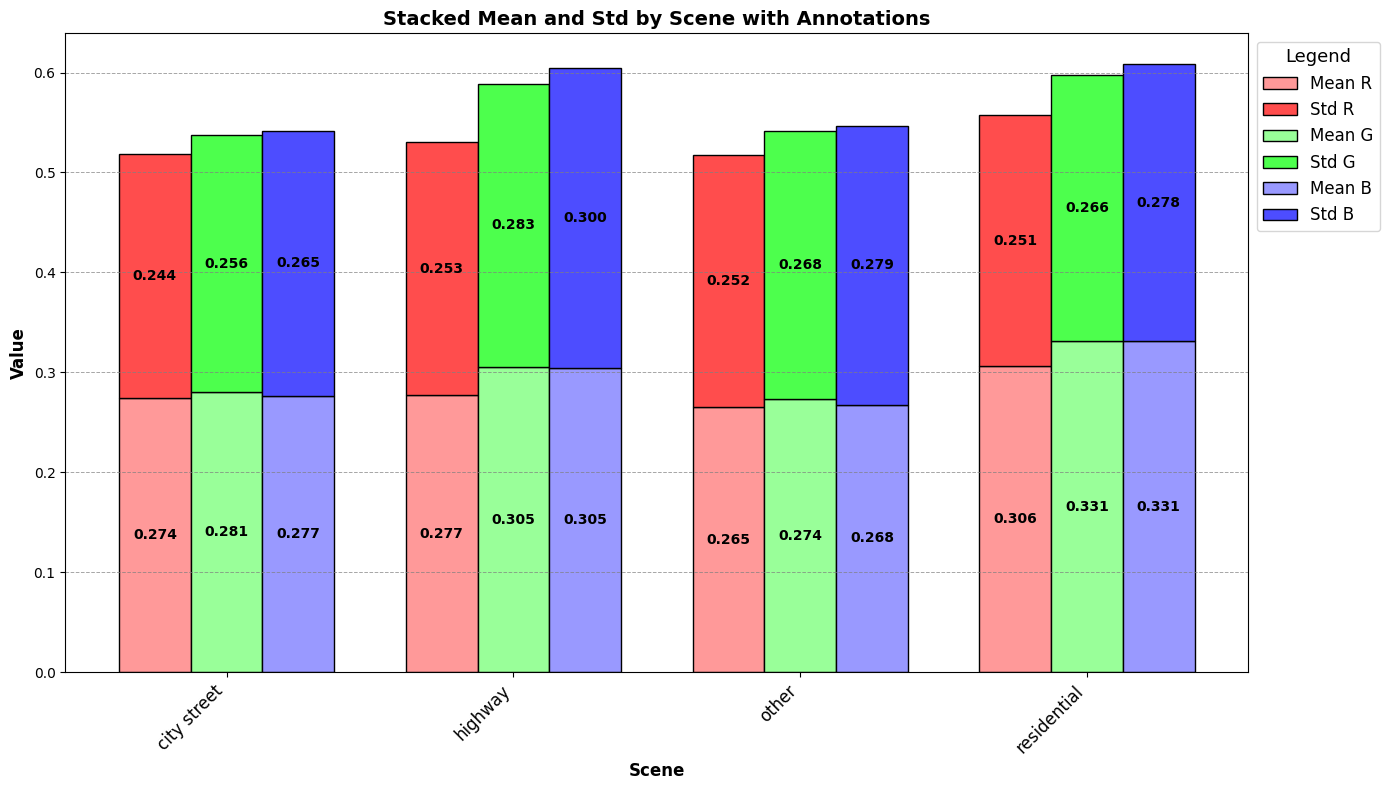

In [ ]:
plot(df_mean)